# Module 5 — Multiple Looks: Peeking, Multiple Testing & Stopping Rules

Part of the **A/B Testing Playbook** learning program. Full program context, progress tracker, and how this module fits with the rest: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - The "peeking" problem — why checking significance repeatedly over time inflates the false-positive rate
> - The same phenomenon along a different axis: multiple testing across many metrics or segments (Bonferroni, FDR — False Discovery Rate — correction) — it's the same "repeated looks" problem, just spatial instead of temporal
> - Sequential testing and always-valid p-values as a principled fix
> - Stopping rules and minimum runtime, and why "stop as soon as it's significant" is wrong
> - Practical monitoring: SRM checks and guardrail regressions surfacing mid-test
>
> **Why it matters**
> At B2C scale, tests are monitored live and there's constant organizational pressure to call results early or highlight whichever metric/segment turned green. Knowing why both are the same statistical trap — and how modern platforms handle it — is a strong credibility signal.
>
> **Worked example**
> Checking a test's p-value every day for two weeks and stopping the moment it crosses 0.05 sounds harmless but isn't: under the null hypothesis (no real effect), that repeated-checking procedure triggers a "significant" result far more than 5% of the time — this is the well-documented finding behind Optimizely's and other platforms' move to sequential/always-valid testing. The fix isn't "don't look" — it's using a testing procedure that stays valid *even if* you look every day.
>
> **Resources**
> - [How Not to Run an A/B Test](https://www.evanmiller.org/how-not-to-run-an-ab-test.html) — Evan Miller (verified, ~15 min)
> - *Peeking at A/B Tests* — Johari, Koomen, Pekelis & Walsh (KDD 2017, verified real; search title)
>
> **Exercise type:** simulation — show empirically (via repeated simulation) how peeking inflates false-positive rate, then implement a simple sequential-testing correction.
>
> **Interview angle:** less common as a direct question, but a strong differentiator when it comes up ("someone wants to end the test early because it's significant — what do you say?").

## Lesson

### The peeking problem

Module 3 built a test that's correct *if you look exactly once*, at a sample size you decided on in advance. Checking a test's p-value every day and stopping the moment it crosses 0.05 breaks that guarantee, for a simple reason: every day you check is another chance for random noise alone to *briefly* push the p-value below 0.05, even when there's truly no effect. You don't need the effect to be real — you just need noise to wobble the right way on any one of many days, and "stop at the first day that happens" guarantees you'll eventually catch one of those wobbles far more often than 5% of the time. Evan Miller's article puts a number on the extreme case: checking continuously and stopping the instant you cross 5% significance inflates the *true* false-positive rate to **26.1%** — over five times the nominal rate. Part 1 below reproduces this empirically at a more realistic "check periodically" cadence, not continuous monitoring.

### The same problem, a different axis

Module 4 flagged this connection; here's the full version. Peeking asks the same question *K* times *over time* on the *same* metric. Testing many metrics or many segments asks the same question *K* times *across* different slices, all at once. Both inflate the same way, for the same underlying reason: **each individual look has a 5% chance of a false positive, and those chances stack up the more looks you take** — whether "more looks" means more days or more segments. Part 2 below derives exactly how much they stack up.

### Sequential testing and always-valid p-values

The principled, industry-grade fix (what Optimizely's platform and the Johari et al. paper actually implement) is a family of methods — **always-valid p-values**, built on **sequential testing** theory (the mSPRT, "mixture sequential probability ratio test," is the specific method in that paper) — that are mathematically constructed to stay valid *no matter how often you look*, without needing you to commit to a fixed checking schedule in advance. That's genuinely more sophisticated math than this module derives from scratch. What we *will* build — the **Bonferroni correction** — is a simpler, more conservative tool that solves both the temporal and spatial versions of this problem with the *same* one idea: if you're going to take *K* looks, test each one at a stricter bar (α/K instead of α), so the *K* chances to be wrong still add up to no more than your original α. It's blunter than always-valid testing (Part 3 shows exactly how much power it costs you), but it's honest, derivable from first principles, and it's the same tool whether "K looks" means K days or K segments.

### Why Bonferroni is rigorous, not just plausible

It's worth being precise here, because "add up the risk" can sound like a hand-wavy approximation — it isn't. The underlying fact is **Boole's inequality** (the "union bound"), a genuine one-line proof that holds no matter what, independent or not: for any events A₁...A_K, P(A₁ ∪ ... ∪ A_K) ≤ P(A₁) + P(A₂) + ... + P(A_K). (This follows from P(A∪B) = P(A) + P(B) − P(A∩B) ≤ P(A) + P(B), since a probability can't be negative, extended to K events by induction.) Let Aᵢ = "look i is a false positive," test each look at level α/K so P(Aᵢ) = α/K exactly, and the bound gives P(at least one false positive) ≤ K × (α/K) = α. That's the entire proof — no independence assumption required anywhere.

What correlation *does* affect is how **tight** that ≤ actually is, not whether it holds. Under independence (Part 2's segments), the bound is nearly exact — little safety margin wasted. Under positive correlation (Part 1's peeks, which share most of their data with each other), the inequality is very loose — a lot of margin gets wasted. That's *why* Part 1's correction overshoots well below 5% while Part 2's lands almost exactly on it: both outcomes are predicted by this one proof, not two separate empirical coincidences.

### Stopping rules and minimum runtime

The practical discipline that avoids this whole problem: decide *before the test starts* how long you'll run it and how many times (if any) you'll look before that point — this is Module 4's pre-registration, applied specifically to the *monitoring* plan. "We'll run this for 2 weeks and look once, at the end" is safe. "We'll look whenever someone asks" is not — even if no one consciously "cheats," the mere act of checking repeatedly and being more likely to stop and report right when a random wobble crosses the line does the damage on its own.

### One exception worth naming explicitly

Not everything counts as "peeking" in the risky sense. **SRM checks and guardrail regressions (Module 4) are validity and safety checks, not outcome decisions** — they're allowed to trigger an immediate stop at any time, because they're not asking "did the primary metric win," they're asking "is this experiment even trustworthy right now, or is something actively broken." The restriction in this module is specifically about repeatedly checking the *primary metric* and treating each check as a fresh chance to declare victory — it was never a rule against monitoring for problems.

### Part 1 — The peeking problem, temporal axis: simulate it, then fix it

Simulating a genuinely null experiment (both groups truly identical) that accumulates data over 20 periodic checks, and asking: if an experimenter looked at every one of those checks and stopped the moment p < 0.05, how often would they falsely call a winner — compared to looking just once, at the end?

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=99)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GOOD = "#1a7f37"
BAD = "#cf222e"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

def z_test_pvalue(x1, n1, x2, n2):
    """Two-proportion z-test p-value -- same formula validated from scratch in Module 3.
    Vectorized: x1/n1/x2/n2 can be scalars or numpy arrays of matching shape."""
    p1, p2 = x1 / n1, x2 / n2
    p_pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pooled * (1 - p_pooled) * (1 / n1 + 1 / n2))
    se_safe = np.where(se == 0, 1, se)          # avoid divide-by-zero
    z = np.where(se == 0, 0, (p2 - p1) / se_safe)  # se=0 means no variance -> treat as z=0, p=1
    return 2 * (1 - stats.norm.cdf(np.abs(z)))

In [2]:
true_rate = 0.05      # SAME rate in both groups -- a genuinely true null, no real effect anywhere
n_checks = 20
n_per_check = 500      # each check adds 500 more users per arm since the last one
n_final = n_checks * n_per_check
n_sims = 3000
alpha = 0.05

# For each simulated experiment, draw the FULL individual-level outcome sequence up front,
# then look at CUMULATIVE totals at each of the 20 checkpoints -- this is what "the same
# experiment accumulating more data over time" actually looks like, not 20 fresh redraws.
control_outcomes = rng.binomial(1, true_rate, size=(n_sims, n_final))
treatment_outcomes = rng.binomial(1, true_rate, size=(n_sims, n_final))

checkpoints = np.arange(n_per_check, n_final + 1, n_per_check)  # 500, 1000, ..., 10000
control_cum = np.cumsum(control_outcomes, axis=1)[:, checkpoints - 1]
treatment_cum = np.cumsum(treatment_outcomes, axis=1)[:, checkpoints - 1]

p_values = np.zeros((n_sims, n_checks))
for j, n_so_far in enumerate(checkpoints):
    p_values[:, j] = z_test_pvalue(control_cum[:, j], n_so_far, treatment_cum[:, j], n_so_far)

crossed_by_check = p_values < alpha
# "ever crossed significance by check k" -- a peeking-and-stop policy would have stopped
# at the FIRST such check, so what matters is whether ANY of checks 1..k crossed
ever_crossed_by_k = np.cumsum(crossed_by_check, axis=1) > 0
false_positive_rate_by_k = ever_crossed_by_k.mean(axis=0)

single_look_rate = crossed_by_check[:, -1].mean()  # looking ONLY at the final check
print(f"Single look at the end only (n={n_final}/arm): false-positive rate = {single_look_rate:.1%}  (target: ~5%)")
print(f"Peeking at all {n_checks} checks, stop at first significant: false-positive rate = {false_positive_rate_by_k[-1]:.1%}")

Single look at the end only (n=10000/arm): false-positive rate = 4.9%  (target: ~5%)
Peeking at all 20 checks, stop at first significant: false-positive rate = 23.9%


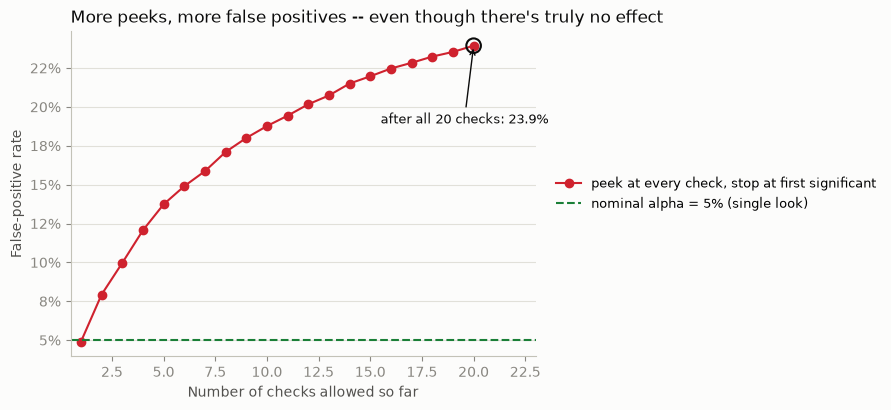

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

ax.plot(range(1, n_checks + 1), false_positive_rate_by_k, color=BAD, linewidth=1.5, marker="o", markersize=6,
        label="peek at every check, stop at first significant")
ax.axhline(alpha, color=GOOD, linewidth=1.5, linestyle="--", label="nominal alpha = 5% (single look)")

# highlight the final marker (check 20) -- this is the exact number the text below refers to
last_x, last_y = n_checks, false_positive_rate_by_k[-1]
ax.scatter([last_x], [last_y], s=110, facecolor="none", edgecolor=INK, linewidth=1.5, zorder=5)
ax.annotate(f"after all {n_checks} checks: {last_y:.1%}",
            xy=(last_x, last_y), xytext=(last_x - 4.5, last_y - 0.05),
            fontsize=9, color=INK, ha="left",
            arrowprops=dict(arrowstyle="->", color=INK, linewidth=1))

ax.set_xlim(0.5, n_checks + 3)
ax.set_xlabel("Number of checks allowed so far", color=INK_SECONDARY)
ax.set_ylabel("False-positive rate", color=INK_SECONDARY)
ax.set_title("More peeks, more false positives -- even though there's truly no effect", color=INK, fontsize=12, loc="left")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.10, right=0.72, top=0.88, bottom=0.14)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.show()

**What this shows:** with only 1 check allowed, the false-positive rate sits right at the nominal 5% (Module 3's guarantee holds when you really do look only once). Allow more checks and it climbs steadily — every additional check is another chance for pure noise to briefly cross the line, and "stop at the first one that does" cashes in on that chance every time it happens. This is a smaller inflation than Evan Miller's 26.1% figure, and that's expected, not a discrepancy: his number is for checking after *every single observation* (continuous monitoring), the most extreme case; this simulation checks only 20 times total. More peeks (or finer-grained ones) push this curve higher, toward his number — same mechanism, different peek frequency.

**The fix — Bonferroni across the 20 looks:** instead of testing each check against alpha = 0.05, test each one against alpha / 20 = 0.0025. Re-running the identical simulation with that stricter bar:

In [4]:
alpha_bonferroni = alpha / n_checks
crossed_bonferroni = p_values < alpha_bonferroni
ever_crossed_bonferroni = (np.cumsum(crossed_bonferroni, axis=1) > 0)[:, -1]
false_positive_rate_bonferroni = ever_crossed_bonferroni.mean()

print(f"Peeking at all {n_checks} checks, Bonferroni-corrected (alpha/{n_checks} = {alpha_bonferroni:.4f} per look):")
print(f"  false-positive rate = {false_positive_rate_bonferroni:.1%}  (target: at or below 5%)")

Peeking at all 20 checks, Bonferroni-corrected (alpha/20 = 0.0025 per look):
  false-positive rate = 1.6%  (target: at or below 5%)


**What this shows — and why it overshoots:** the corrected rate (1.6%) doesn't just come back to 5%, it drops well *below* it — Bonferroni didn't just fix the problem here, it overcorrected. That's a real, informative pattern, not noise: Bonferroni's alpha/K math assumes the K looks are independent, and these 20 checks are anything but — each one shares almost all its data with the checks before and after it (checkpoint 12 is checkpoint 11 plus 500 more observations), so they're heavily correlated. Under positive correlation, Bonferroni is known to be *extra* conservative, because a look that's borderline tends to stay borderline on nearby looks rather than getting a fresh independent chance to cross the corrected bar. Compare this to Part 2 below, where segments really are independent and Bonferroni lands almost exactly on 5% — the gap between "almost exact" there and "well under" here is precisely why real platforms don't use plain Bonferroni for the *temporal* peeking problem, and instead reach for the sequential/always-valid methods this module's lesson named (mSPRT, Johari et al.) — Bonferroni works for peeking, it's just needlessly expensive.

### Part 2 — The same problem, spatial axis: multiple segments

Now the other axis: no peeking over time at all — one single look, at a fixed sample size, exactly as Module 3 intended. But this time across 20 independent segments simultaneously (all truly null — no real difference anywhere), asking whether *any* of them comes back falsely significant.

**Deriving the expected rate first, before simulating:** for one test at alpha = 5%, the chance of *no* false positive is (1 − 0.05) = 0.95. For 20 *independent* tests, the chance that *none* of them is a false positive is 0.95 multiplied by itself 20 times: 0.95²⁰. So the chance that *at least one* comes back falsely significant is 1 − 0.95²⁰.

In [5]:
k_segments = 20
predicted_at_least_one = 1 - (1 - alpha) ** k_segments
all_clean_probability = (1 - alpha) ** k_segments

print(f"Single test: {1 - alpha:.0%} chance of staying clean, {alpha:.0%} chance of a false positive.")
print(f"All {k_segments} independent tests staying clean: (1-{alpha})^{k_segments} = {all_clean_probability:.1%}")
print(f"So P(at least one false positive) = 1 - {all_clean_probability:.1%} = {predicted_at_least_one:.1%}")

# The same formula at k=1 -- its own "respective number" -- for direct comparison
predicted_k1 = 1 - (1 - alpha) ** 1
print(f"\nCompare to a single segment (k=1): P(at least one false positive) = {predicted_k1:.1%}"
      f"  -- this IS just alpha, trivially, since there's only one test to go wrong")
print(f"20 segments vs. 1: {predicted_at_least_one:.1%} / {predicted_k1:.1%} = {predicted_at_least_one / predicted_k1:.1f}x higher"
      f" -- NOT 20x, because \"at least one\" doesn't double-count: a run where two different segments"
      f" both misfire only counts once, so each added segment contributes a shrinking amount of new risk")

Single test: 95% chance of staying clean, 5% chance of a false positive.
All 20 independent tests staying clean: (1-0.05)^20 = 35.8%
So P(at least one false positive) = 1 - 35.8% = 64.2%

Compare to a single segment (k=1): P(at least one false positive) = 5.0%  -- this IS just alpha, trivially, since there's only one test to go wrong
20 segments vs. 1: 64.2% / 5.0% = 12.8x higher -- NOT 20x, because "at least one" doesn't double-count: a run where two different segments both misfire only counts once, so each added segment contributes a shrinking amount of new risk


In [6]:
n_per_segment = 2500  # per arm, per segment

# All 20 segments are TRULY null here -- same true rate in control and treatment, every segment
control_counts = rng.binomial(n_per_segment, true_rate, size=(n_sims, k_segments))
treatment_counts = rng.binomial(n_per_segment, true_rate, size=(n_sims, k_segments))

segment_pvalues = z_test_pvalue(control_counts, n_per_segment, treatment_counts, n_per_segment)
any_significant = (segment_pvalues < alpha).any(axis=1)
empirical_at_least_one = any_significant.mean()

print(f"Empirical P(at least one false positive among {k_segments} segments), from {n_sims:,} simulated experiments: {empirical_at_least_one:.1%}")
print(f"Predicted from the formula above: {predicted_at_least_one:.1%}")

Empirical P(at least one false positive among 20 segments), from 3,000 simulated experiments: 61.7%
Predicted from the formula above: 64.2%


**What this shows:** the simulation lands close to the formula's prediction (61.7% empirical vs. 64.2% predicted) — and unlike a check that would only confirm already-trusted math (Module 4's circularity lesson), this comparison could genuinely have failed: we derived a *new* prediction from first principles (1 − 0.95²⁰) before ever running the simulation, and checked whether the world actually behaves that way. It mostly does; the small remaining gap is the same mild conservatism the z-test already showed in Module 3 (there, a single look measured ~4.9% instead of exactly 5.0%) — the normal-approximation test's *true* per-test false-positive rate runs slightly under its nominal 5% at these sample sizes, so 20 slightly-under-5%-each tests compound to a bit less than the formula's assumption of exactly 5% each. The formula isn't wrong; it's answering "what if each test is exactly 5%," and reality is answering "what this specific test actually does," which are subtly different questions.

And the number itself is worth sitting with regardless of the small gap: test 20 truly-null segments and you have roughly a **two-in-three chance** of "finding" something that isn't there, using nothing but the standard 5% bar per test.

**The fix is the same Bonferroni idea, applied to segments instead of days:** test each segment against alpha / 20 instead of alpha.

In [7]:
alpha_bonferroni_segments = alpha / k_segments
any_significant_bonferroni = (segment_pvalues < alpha_bonferroni_segments).any(axis=1)
empirical_bonferroni_segments = any_significant_bonferroni.mean()

print(f"Bonferroni-corrected (alpha/{k_segments} = {alpha_bonferroni_segments:.4f} per segment):")
print(f"  P(at least one false positive) = {empirical_bonferroni_segments:.1%}  (target: back down near 5%)")

Bonferroni-corrected (alpha/20 = 0.0025 per segment):
  P(at least one false positive) = 4.2%  (target: back down near 5%)


### Part 3 — Bonferroni's real cost: a power tradeoff against Benjamini-Hochberg (FDR)

Bonferroni fixes the false-positive problem, but Module 3 already taught that a stricter significance bar costs power (fewer true effects get detected). This part makes that cost concrete, and introduces the **Benjamini-Hochberg** procedure — a different way of controlling false discoveries that trades perfect false-positive control for meaningfully better power. Same 20 segments, but now **5 of the 20 have a real effect** (5% → 6.5% conversion) and 15 are truly null — a realistic mix, not an all-or-nothing scenario.

In [8]:
def benjamini_hochberg(p_values, q=0.05):
    """Returns a boolean array: which p-values are significant under FDR control at level q."""
    m = len(p_values)
    order = np.argsort(p_values)
    sorted_p = p_values[order]
    thresholds = (np.arange(1, m + 1) / m) * q
    passes = sorted_p <= thresholds
    if not passes.any():
        return np.zeros(m, dtype=bool)
    largest_k = np.max(np.where(passes)[0])  # largest index where sorted p <= its threshold
    reject = np.zeros(m, dtype=bool)
    reject[order[:largest_k + 1]] = True
    return reject

n_true_effect = 5
n_null = k_segments - n_true_effect
true_effect_rate = 0.065

# columns 0-4: true effect: columns 5-19: truly null
control_mixed = rng.binomial(n_per_segment, true_rate, size=(n_sims, k_segments))
treatment_mixed = np.empty((n_sims, k_segments), dtype=int)
treatment_mixed[:, :n_true_effect] = rng.binomial(n_per_segment, true_effect_rate, size=(n_sims, n_true_effect))
treatment_mixed[:, n_true_effect:] = rng.binomial(n_per_segment, true_rate, size=(n_sims, n_null))

mixed_pvalues = z_test_pvalue(control_mixed, n_per_segment, treatment_mixed, n_per_segment)

is_true_effect = np.zeros(k_segments, dtype=bool)
is_true_effect[:n_true_effect] = True

results = {}
for label, flagged in [
    ("Uncorrected (alpha=0.05)", mixed_pvalues < alpha),
    (f"Bonferroni (alpha/{k_segments})", mixed_pvalues < alpha / k_segments),
    ("Benjamini-Hochberg (q=0.05)", np.array([benjamini_hochberg(mixed_pvalues[i]) for i in range(n_sims)])),
]:
    true_positive_rate = flagged[:, is_true_effect].mean()     # of the 5 real effects, how many get caught, on average
    false_positive_rate = flagged[:, ~is_true_effect].any(axis=1).mean()  # any false alarm among the 15 nulls
    results[label] = (true_positive_rate, false_positive_rate)

summary = pd.DataFrame(results, index=["true effects detected (avg. of 5)", "P(>=1 false positive among 15 nulls)"]).T
summary["true effects detected (avg. of 5)"] = summary["true effects detected (avg. of 5)"] * 5
print(summary.round(3))

                             true effects detected (avg. of 5)  \
Uncorrected (alpha=0.05)                                 3.099   
Bonferroni (alpha/20)                                    1.124   
Benjamini-Hochberg (q=0.05)                              1.570   

                             P(>=1 false positive among 15 nulls)  
Uncorrected (alpha=0.05)                                    0.538  
Bonferroni (alpha/20)                                       0.039  
Benjamini-Hochberg (q=0.05)                                 0.105  


**What the numbers mean — and why there's no objectively "best" answer here:** whether Benjamini-Hochberg's tradeoff (catching 1.57 vs. 3.10 of the 5 real effects, in exchange for a false-positive rate of 10.5% vs. Bonferroni's 3.9%) is "worth it" isn't something these numbers can settle by themselves — it depends entirely on how costly a false positive is to you versus how costly a missed real effect is, and that's a business judgment, not a statistical one. What the statistics *can* tell you is the shape of the tradeoff, precisely:

- **Uncorrected** catches the most real effects but also has the highest false-positive rate — no surprise, it's not protecting against anything.
- **Bonferroni** brings the false-positive rate down hardest, at the cost of missing noticeably more of the 5 genuine effects — the power Module 3 warned a stricter bar always costs.
- **Benjamini-Hochberg** sits in between by design: it doesn't promise "at most a 5% chance of *any* false positive" the way Bonferroni does — it promises "of whatever I *do* flag as significant, at most about 5% of those flags will be wrong, on average." That's a different, looser guarantee (control the *rate* of false discoveries among discoveries, not the *chance* of even one), which is exactly what buys back some power.

As a rule of thumb: reach for Bonferroni when *any* false positive is costly (e.g. a safety-relevant guardrail); reach for Benjamini-Hochberg when you're scanning many segments for promising leads and can tolerate a few of today's "discoveries" turning out wrong later. Neither choice is free, and neither is universally correct.

## Key takeaways

- Peeking and multiple testing are the same mathematical problem on two different axes — more looks (over time, or across segments) means more chances for noise alone to cross your significance bar
- A single planned look really does hold at the nominal false-positive rate (Module 3's guarantee) — the inflation is specifically a consequence of *repeated, unplanned* looks with a stop-at-first-significant policy
- Bonferroni (alpha / number-of-looks) fixes both the temporal and spatial versions of this problem with one simple, derivable idea — at the cost of real statistical power
- Benjamini-Hochberg (FDR control), demonstrated here on the spatial axis (segments), is a genuinely different, less conservative alternative to Bonferroni — worth knowing it exists and what tradeoff it makes
- Separately, for the *temporal* axis specifically (peeking): real platforms mostly skip Bonferroni-style correction entirely in favor of the more sophisticated always-valid/sequential methods this module's lesson named (mSPRT, Johari et al.) — Bonferroni works there too, it's just needlessly conservative, as Part 1 showed
- SRM checks and guardrail regressions are exempt from "don't peek" — they're validity checks, not a second chance to declare victory on the primary metric

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*